In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str((Path.cwd() / '..').resolve()))

from ml.training import train_model_from_event_dirs
from ml.trainers import TrainingConfig

/home/divan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [6]:
DATA_DIR = (Path.cwd() / '..' / 'data' / 'train').resolve()

baseline_cfg = TrainingConfig(model_type='logistic_regression', val_ratio=0.2, seed=42, iterations=3000, l2=1e-3)
prod_cfg = TrainingConfig(model_type='random_forest', val_ratio=0.2, seed=42, random_forest_trees=300)

baseline = train_model_from_event_dirs(DATA_DIR, config=baseline_cfg)
production = train_model_from_event_dirs(DATA_DIR, config=prod_cfg)

baseline.val_metrics, production.val_metrics

({'log_loss': 0.0003500948715795542,
  'brier_score': 2.1418514393400271e-07,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'false_positive_rate': 0.0,
  'threshold': 0.5,
  'tp': 1,
  'tn': 1,
  'fp': 0,
  'fn': 0,
  'roc_auc': 1.0},
 {'log_loss': 0.06434616308220972,
  'brier_score': 0.005027777777777779,
  'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'false_positive_rate': 0.0,
  'threshold': 0.5,
  'tp': 1,
  'tn': 1,
  'fp': 0,
  'fn': 0,
  'roc_auc': 1.0})

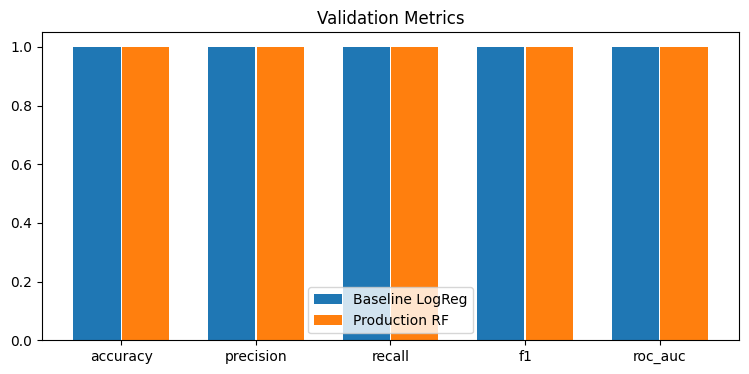

In [7]:
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
baseline_vals = [baseline.val_metrics.get(name) or 0.0 for name in metric_names]
prod_vals = [production.val_metrics.get(name) or 0.0 for name in metric_names]

x = range(len(metric_names))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - 0.18 for i in x], baseline_vals, width=0.35, label='Baseline LogReg')
ax.bar([i + 0.18 for i in x], prod_vals, width=0.35, label='Production RF')
ax.set_ylim(0, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(metric_names)
ax.set_title('Validation Metrics')
ax.legend()
plt.show()